# Baseline Model Training

## Objective
Train several machine learning models using the same preprocessing pipeline and compare their performance

## Import Libraries

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    classification_report
)

## Load Dataset

In [2]:
df = pd.read_csv("../data/processed/cleveland_clean.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,3,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0


## Prepare Data

In [3]:
X = df.drop(columns="target")

y = df["target"]

numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state=42,
    stratify=y
)

## Create Preprocessor

In [4]:
# Numerical pipeline
numerical_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

# Categorical pipeline - leave them as they are, as they are already int-coded
categorical_pipeline = "passthrough"


# Combination
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

## Models

In [5]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(random_state=42,probability=True)
}

In [6]:
results = []

for model_name,model in models.items():
    pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
    )
    pipeline.fit(X_train,y_train)
    
    y_pred = pipeline.predict(X_test)

    y_prob = pipeline.predict_proba(X_test)[:,1]

    roc_auc = roc_auc_score(y_test,y_prob)
    
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)
    
    results.append({
    "Model": model_name,
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "ROC-AUC": roc_auc
    })

/home/san/workspace/hackathon/medical-risk-ai/myenv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


## Comparision Table

In [7]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.868852,0.812500,0.928571,0.866667,0.951299
1,Decision Tree,0.770492,0.705882,0.857143,0.774194,0.777056
2,Random Forest,0.918033,0.870968,0.964286,0.915254,0.954004
3,KNN,0.786885,0.741935,0.821429,0.779661,0.867424
4,SVM,0.819672,0.774194,0.857143,0.813559,0.919913


In [8]:
results_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Random Forest,0.918033,0.870968,0.964286,0.915254,0.954004
0,Logistic Regression,0.868852,0.812500,0.928571,0.866667,0.951299
4,SVM,0.819672,0.774194,0.857143,0.813559,0.919913
3,KNN,0.786885,0.741935,0.821429,0.779661,0.867424
1,Decision Tree,0.770492,0.705882,0.857143,0.774194,0.777056


In [9]:
results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Random Forest,0.918033,0.870968,0.964286,0.915254,0.954004
0,Logistic Regression,0.868852,0.812500,0.928571,0.866667,0.951299
4,SVM,0.819672,0.774194,0.857143,0.813559,0.919913
3,KNN,0.786885,0.741935,0.821429,0.779661,0.867424
1,Decision Tree,0.770492,0.705882,0.857143,0.774194,0.777056


## Confusion Matrix

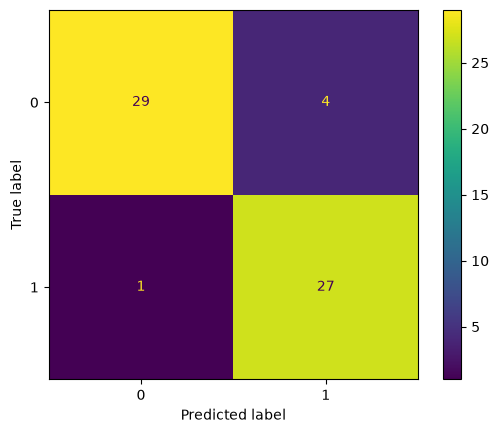

In [10]:
best_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(random_state=42))
    ]
)

best_pipeline.fit(X_train, y_train)

ConfusionMatrixDisplay.from_estimator(
    best_pipeline,
    X_test,
    y_test
)

## Calssification Report

In [11]:
y_pred = best_pipeline.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.88      0.92        33
           1       0.87      0.96      0.92        28

    accuracy                           0.92        61
   macro avg       0.92      0.92      0.92        61
weighted avg       0.92      0.92      0.92        61



## Visual Comparision

### Accuracy

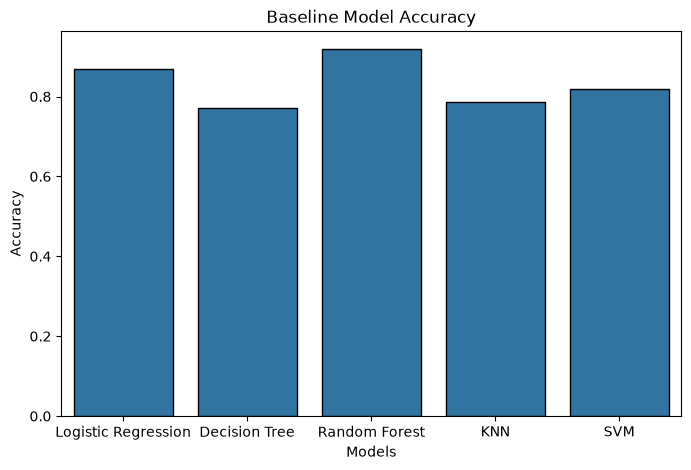

In [16]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy",
    edgecolor="black",
    linewidth=1
)
plt.title("Baseline Model Accuracy")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

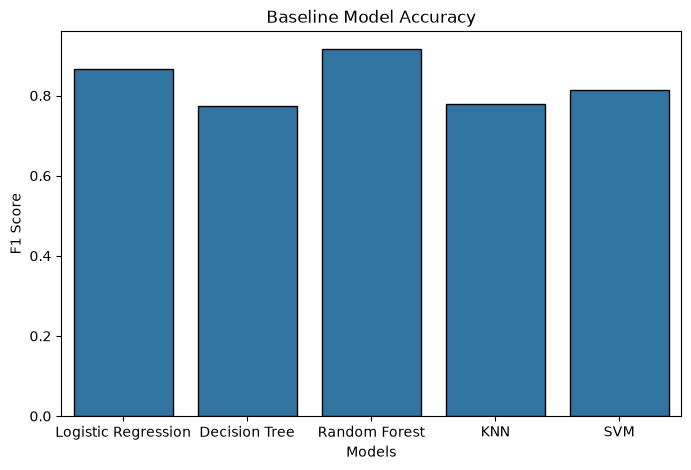

In [17]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="F1 Score",
    edgecolor="black",
    linewidth=1
)
plt.title("Baseline Model Accuracy")
plt.xlabel("Models")
plt.ylabel("F1 Score")
plt.show()

# Baseline Model Comparison

- Five baseline classifiers were trained.
- All models used the same preprocessing pipeline.
- Evaluation was performed on the same held-out test set.
- Here Random forest achieved the highest accuracy, F1 Score, adn ROC-AUC, indicating it captured the complex, non-linear relationships bettern than linear and distance based models
- So we have selected it for hyperparameter tuning.